<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Voting_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [15]:
path=kagglehub.dataset_download("shivam2503/diamonds")
path

100%|██████████| 733k/733k [00:00<00:00, 85.6MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/shivam2503/diamonds/versions/1'

In [16]:
import os
os.listdir(path)

['diamonds.csv']

A data frame with 53940 rows and 10 variables:

**price**

price in US dollars (\$326--\$18,823)

**carat**

weight of the diamond (0.2--5.01)

**cut**

quality of the cut (Fair, Good, Very Good, Premium, Ideal)

**color**

diamond colour, from J (worst) to D (best)

**clarity**

a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))

**x**

length in mm (0--10.74)

**y**

width in mm (0--58.9)

**z**

depth in mm (0--31.8)

**depth**

total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)

**table**

width of top of diamond relative to widest point (43--95)

In [18]:
df=pd.read_csv(path+"/diamonds.csv")

In [19]:
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [20]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [26]:
df.sample(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
14811,1.04,4,3,5,61.3,58.0,5964,6.45,6.53,3.98
45765,0.61,2,4,4,61.6,56.9,1706,5.40,5.49,3.36
36875,0.39,2,2,4,62.3,57.0,958,4.65,4.69,2.91
38104,0.36,3,1,5,62.1,59.0,1013,4.59,4.55,2.84
52047,0.80,3,3,3,61.4,56.0,2451,5.99,5.96,3.67


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler


In [25]:
le=LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
x_train,x_test,y_train,y_test=train_test_split(df.drop("price",axis=1),df["price"],test_size=0.2,random_state=42)

In [28]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [29]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((43152, 9), (10788, 9), (43152,), (10788,))

In [30]:
x_train

array([[ 2.56005606, -1.51451263, -0.3479487 , ...,  2.22945022,
         2.13820916,  1.73820671],
       [ 0.44739205,  1.40673934, -0.93662126, ...,  0.74754991,
         0.65671016,  0.5377332 ],
       [ 0.63753181,  0.43298868,  0.82939642, ...,  0.76540413,
         0.70028366,  0.79195112],
       ...,
       [-0.98921948,  1.40673934, -0.3479487 , ..., -1.10928903,
        -1.11237394, -1.18529936],
       [ 0.21499901,  0.43298868,  2.00674153, ...,  0.35475706,
         0.25583396,  0.39650102],
       [ 0.72203837,  0.43298868, -0.3479487 , ...,  0.97072767,
         0.91815116,  0.80607434]])

In [33]:
x_train=pd.DataFrame(x_train,columns=df.drop("price",axis=1).columns)
x_test=pd.DataFrame(x_test,columns=df.drop("price",axis=1).columns)

In [31]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

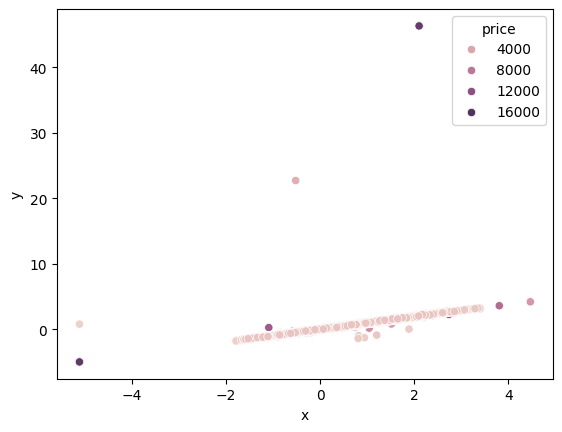

In [38]:
sns.scatterplot(
    data=x_train,
    x='x',
    y='y',
    hue=y_train
)
plt.show()

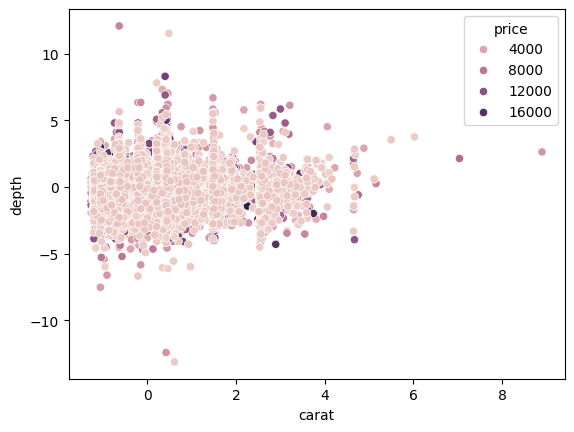

In [36]:
sns.scatterplot(
    data=x_train,
    x='carat',
    y='depth',
    hue=y_train
)
plt.show()

In [43]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

In [44]:
lr=LinearRegression()
dt=DecisionTreeRegressor()
knn=KNeighborsRegressor()
svr=SVR()

In [48]:
estimators=[('lr',lr),('dt',dt),('knn',knn)]

In [46]:
for i in estimators:
  i[1].fit(x_train,y_train)
  y_pred=i[1].predict(x_test)
  print(i[0],":",r2_score(y_test,y_pred))

lr : 0.8851397433679632
dt : 0.9671060588253244
knn : 0.9584411391274588
svr : 0.5145288727741113


In [49]:
vt=VotingRegressor(estimators)
vt.fit(x_train,y_train)
y_pred=vt.predict(x_test)
print(r2_score(y_test,y_pred))

0.9647180860252378
